In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pypfopt import EfficientFrontier, risk_models, plotting

from data_loader import load_local_data

In [2]:
TICKERS = ['TSLA', 'BND', 'SPY']
data = load_local_data(TICKERS, save_dir='../data/processed')

prices = pd.concat([data['TSLA']['Close'], data['BND']['Close'], data['SPY']['Close']], axis=1)
prices.columns = ['TSLA', 'BND', 'SPY']
prices = prices.dropna()

daily_returns = prices.pct_change().dropna()
prices.head()

,TSLA,BND,SPY
Date,,,
2015-01-02,14.620667,82.650002,205.429993
2015-01-05,14.006000,82.889999,201.720001
2015-01-06,14.085333,83.129997,199.820007
2015-01-07,14.063333,83.180000,202.309998
2015-01-08,14.041333,83.050003,205.899994


In [3]:
with open('../data/processed/forecast_summary.json', 'r') as f:
    forecast_summary = json.load(f)

tsla_annual_return = forecast_summary['annualized_forecast_return']
print(f"TSLA forecasted annual return: {tsla_annual_return*100:.2f}%")

TSLA forecasted annual return: -44.26%


In [4]:
bnd_annual_return = daily_returns['BND'].mean() * 252
spy_annual_return = daily_returns['SPY'].mean() * 252

mu = pd.Series({
    'TSLA': tsla_annual_return,
    'BND': bnd_annual_return,
    'SPY': spy_annual_return
})
mu

TSLA   -0.442578
BND    -0.008548
SPY     0.127746
dtype: float64

In [5]:
S = risk_models.sample_cov(prices, returns_data=False, frequency=252)
S

,TSLA,BND,SPY
TSLA,0.326926,0.001793,0.049795
BND,0.001793,0.002883,0.001045
SPY,0.049795,0.001045,0.031402


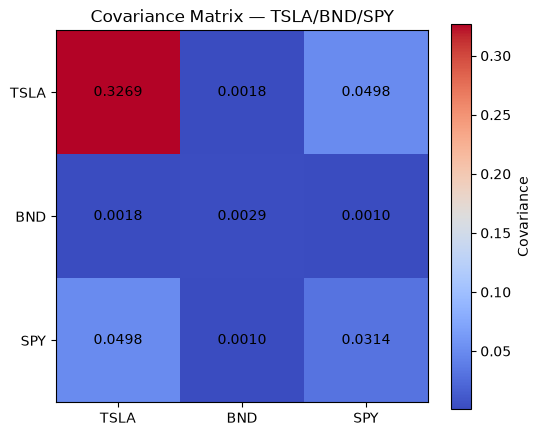

In [6]:
plt.figure(figsize=(6, 5))
plt.imshow(S, cmap='coolwarm')
plt.xticks(range(3), S.columns)
plt.yticks(range(3), S.columns)
plt.colorbar(label='Covariance')
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{S.iloc[i,j]:.4f}", ha='center', va='center')
plt.title('Covariance Matrix — TSLA/BND/SPY')
plt.show()

In [7]:
ef = EfficientFrontier(mu, S)
ef.max_sharpe()
max_sharpe_weights = ef.clean_weights()
ret_ms, vol_ms, sharpe_ms = ef.portfolio_performance()

print("Max Sharpe Portfolio:", max_sharpe_weights)
print(f"Return: {ret_ms*100:.2f}%, Volatility: {vol_ms*100:.2f}%, Sharpe: {sharpe_ms:.3f}")

Max Sharpe Portfolio: OrderedDict({'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0})
Return: 12.77%, Volatility: 17.72%, Sharpe: 0.721


In [8]:
ef_minvol = EfficientFrontier(mu, S)
ef_minvol.min_volatility()
min_vol_weights = ef_minvol.clean_weights()
ret_mv, vol_mv, sharpe_mv = ef_minvol.portfolio_performance()

print("Min Volatility Portfolio:", min_vol_weights)
print(f"Return: {ret_mv*100:.2f}%, Volatility: {vol_mv*100:.2f}%, Sharpe: {sharpe_mv:.3f}")

Min Volatility Portfolio: OrderedDict({'TSLA': 0.0, 'BND': 0.94291, 'SPY': 0.05709})
Return: -0.08%, Volatility: 5.27%, Sharpe: -0.015


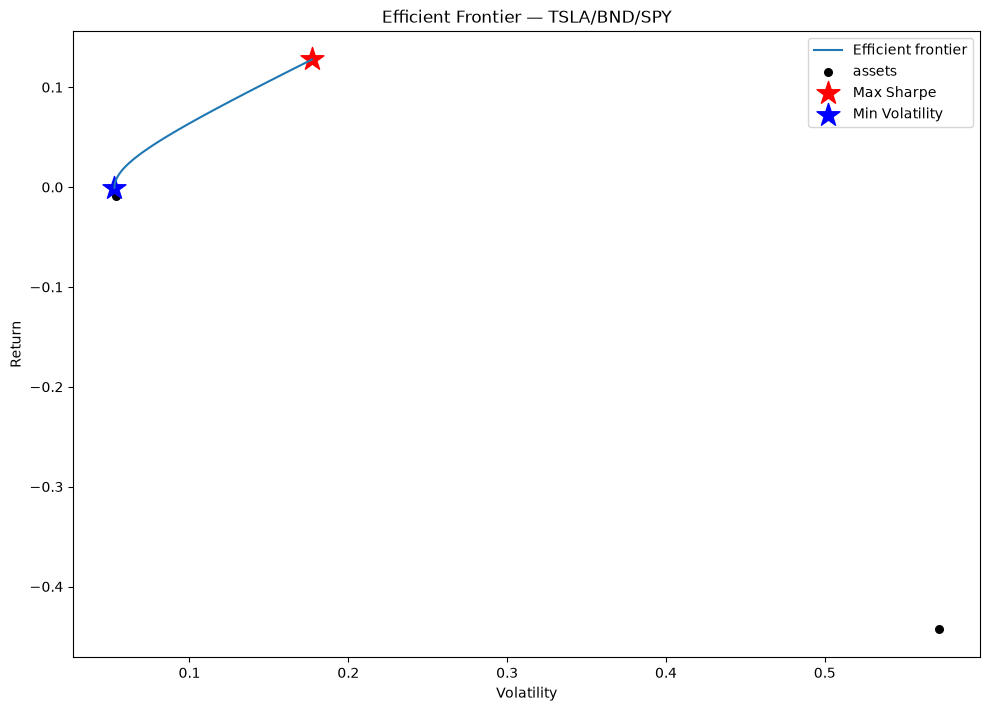

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

ax.scatter(vol_ms, ret_ms, marker='*', s=300, c='red', label='Max Sharpe')
ax.scatter(vol_mv, ret_mv, marker='*', s=300, c='blue', label='Min Volatility')
ax.legend()
plt.title('Efficient Frontier — TSLA/BND/SPY')
plt.show()

In [10]:
# Choose based on your risk preference — Max Sharpe is the common default recommendation
recommended_weights = max_sharpe_weights
recommended_return = ret_ms
recommended_vol = vol_ms
recommended_sharpe = sharpe_ms

print("Recommended Portfolio (Max Sharpe / Tangency):")
for asset, w in recommended_weights.items():
    print(f"  {asset}: {w*100:.2f}%")
print(f"Expected Annual Return: {recommended_return*100:.2f}%")
print(f"Expected Volatility: {recommended_vol*100:.2f}%")
print(f"Sharpe Ratio: {recommended_sharpe:.3f}")

Recommended Portfolio (Max Sharpe / Tangency):
  TSLA: 0.00%
  BND: 0.00%
  SPY: 100.00%
Expected Annual Return: 12.77%
Expected Volatility: 17.72%
Sharpe Ratio: 0.721


In [11]:
portfolio_summary = {
    'weights': dict(recommended_weights),
    'expected_return': recommended_return,
    'expected_volatility': recommended_vol,
    'sharpe_ratio': recommended_sharpe
}

with open('../data/processed/portfolio_summary.json', 'w') as f:
    json.dump(portfolio_summary, f)

print("Portfolio summary saved for Task 5.")

Portfolio summary saved for Task 5.


### Portfolio Recommendation Justification

Both optimized portfolios allocate **0% to TSLA**, which is a direct and rational consequence of the
-44.26% annualized return forecasted in Task 3 — the optimizer correctly recognizes that no amount of
diversification benefit justifies holding an asset with a deeply negative expected return, and excludes
it entirely from both efficient portfolios.

Between the two remaining options, the **Max Sharpe (Tangency) Portfolio** is recommended. It allocates
100% to SPY, delivering an expected annual return of **12.77%** with volatility of **17.72%** and a
Sharpe ratio of **0.721** — meaningfully higher risk-adjusted performance than the Min Volatility
Portfolio, which allocates 94.3% to BND and 5.7% to SPY for a return of **-0.08%**, volatility of
**5.27%**, and a **negative Sharpe ratio of -0.015**. The Min Volatility portfolio technically minimizes
risk, but it does so at the cost of an expected return that is essentially zero (and slightly negative),
meaning an investor would be taking on market risk for no compensated return — a poor risk-adjusted
trade-off. The Max Sharpe portfolio, by contrast, offers substantially higher expected return per unit
of risk taken, making it the more efficient choice for an investor willing to accept moderate volatility
in exchange for a meaningfully positive return. Given GMF's mandate to optimize risk-adjusted performance
rather than minimize risk in isolation, the Max Sharpe Portfolio (100% SPY) is the recommended allocation.